In [ ]:
from config import mpAPI
mpAPI = "oM8Dn5NdnFzwit5MyRA6LqEbqmfuM417"
from mp_api.client import MPRester
from emmet.core.summary import HasProps
from emmet.core.electronic_structure import BSPathType
from pymatgen.electronic_structure.plotter import BSPlotter, DosPlotter
from pymatgen.phonon.plotter import PhononBSPlotter, PhononDosPlotter
from pymatgen.electronic_structure.core import Spin
import json

# Summary Queries

## Structure data for silicon (mp-149)

In [48]:
with MPRester(mpAPI) as mpr:
    docs = mpr.materials.summary.search(
        material_ids = ["mp-149"],
        fields = ["structure"],
    )
    structure = docs[0].structure
    #Shortcut for a single MPID:
    structure = mpr.get_structure_by_material_id("mp-149")

Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<?, ?it/s]


## Querying ICSD ID

In [49]:
with MPRester(mpAPI) as mpr:
    mp_docs = mpr.materials.summary.search(
        material_ids=["mp-149", "mp-13", "mp-22526"],
        fields = ["material_id",
                  "database_IDs"]
    )
icsd_to_mpid = {}
for mp_doc in mp_docs:
    mpid = str(mp_doc.material_id)
    for icsd_id in mp_doc.database_IDs.get("icsd", []):
        if icsd_id not in icsd_to_mpid:
            icsd_to_mpid[icsd_id] = []
        icsd_to_mpid[icsd_id].append(mpid)

Retrieving SummaryDoc documents: 100%|██████████| 3/3 [00:00<?, ?it/s]


In [50]:
icsd_to_mpid
#Not every ICSD entry is included in Materials Project

{'icsd-76268': ['mp-149'],
 'icsd-181356': ['mp-149'],
 'icsd-659044': ['mp-149'],
 'icsd-60388': ['mp-149'],
 'icsd-652258': ['mp-149'],
 'icsd-652257': ['mp-149'],
 'icsd-67788': ['mp-149'],
 'icsd-51688': ['mp-149'],
 'icsd-652265': ['mp-149'],
 'icsd-29287': ['mp-149'],
 'icsd-43610': ['mp-149'],
 'icsd-52266': ['mp-149'],
 'icsd-52457': ['mp-149'],
 'icsd-43403': ['mp-149'],
 'icsd-53783': ['mp-149'],
 'icsd-181907': ['mp-149'],
 'icsd-181355': ['mp-149'],
 'icsd-652255': ['mp-149'],
 'icsd-60389': ['mp-149'],
 'icsd-60385': ['mp-149'],
 'icsd-182730': ['mp-149'],
 'icsd-29288': ['mp-149'],
 'icsd-150530': ['mp-149'],
 'icsd-94261': ['mp-149'],
 'icsd-60386': ['mp-149'],
 'icsd-60387': ['mp-149'],
 'icsd-426975': ['mp-149'],
 'icsd-41979': ['mp-149'],
 'icsd-53782': ['mp-149'],
 'icsd-191759': ['mp-149'],
 'icsd-159354': ['mp-13'],
 'icsd-52258': ['mp-13'],
 'icsd-159353': ['mp-13'],
 'icsd-64999': ['mp-13'],
 'icsd-180970': ['mp-13'],
 'icsd-159352': ['mp-13'],
 'icsd-631722': ['

## Find MPIDs with dielectric data

In [ ]:
with MPRester(mpAPI) as mpr:
    mp_docs = mpr.materials.summary.search(
        material_ids=["mp-149", "mp-13", "mp-22526"],
        has_props = [HasProps.dielectric],
        fields = ["material_id"]
    )

mp_docs

## Calculation (task) IDs and types for silicon (mp-149)

In [ ]:
with MPRester(mpAPI) as mpr:
    # Notice the distinction between: mpr.materials.search(...) and mpr.materials.summary.search(...)
    
    # mpr.materials.search(...) accesses the core materials collection and exposes lower-level calculation data such as calc_types, which maps
    # a single material_id to many associated task_ids/workflows.
    
    # mpr.materials.summary.search(...) accesses the aggregated summary document, where properties are consolidated into a single representative material entry. 
    # Fields such as "origins" therefore  typically point to one selected task_id that serves as the provenance for a specific summarized property 
    # (e.g., structure).

    docs = mpr.materials.search(
        material_ids = ["mp-149"],
        fields = ["calc_types"]
    )
    task_ids = docs[0].calc_types.keys()
    task_types = docs[0].calc_types.values()

    task_ids = mpr.get_task_ids_associated_with_material_id("mp-149")


Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<?, ?it/s]


In [ ]:
task_ids_mp149 = {task_ids[i]: list(task_types)[i] for i in range(len(task_ids))}
print(task_ids_mp149)

{MPID(mp-655585): <CalcType.GGA_Static: 'GGA Static'>, MPID(mp-656511): <CalcType.GGA_NSCF_Line: 'GGA NSCF Line'>, MPID(mp-655936): <CalcType.GGA_NSCF_Line: 'GGA NSCF Line'>, MPID(mp-11721): <CalcType.GGA_Structure_Optimization: 'GGA Structure Optimization'>, MPID(mp-149): <CalcType.GGA_Structure_Optimization: 'GGA Structure Optimization'>, MPID(mp-1057373): <CalcType.GGA_Static: 'GGA Static'>, MPID(mp-1057366): <CalcType.GGA_Structure_Optimization: 'GGA Structure Optimization'>, MPID(mp-1057380): <CalcType.GGA_NSCF_Line: 'GGA NSCF Line'>, MPID(mp-1059585): <CalcType.GGA_Structure_Optimization: 'GGA Structure Optimization'>, MPID(mp-1059589): <CalcType.GGA_Static: 'GGA Static'>, MPID(mp-1059603): <CalcType.GGA_NSCF_Line: 'GGA NSCF Line'>, MPID(mp-1120258): <CalcType.GGA_Structure_Optimization: 'GGA Structure Optimization'>, MPID(mp-1120259): <CalcType.GGA_Structure_Optimization: 'GGA Structure Optimization'>, MPID(mp-1141021): <CalcType.GGA_DFPT_Dielectric: 'GGA DFPT Dielectric'>, MPID

## Bandgap for All Materials Containing Si and O

In [ ]:
from mp_api.client import MPRester

with MPRester(mpAPI) as mpr:
    docs = mpr.materials.summary.search(
        chemsys="Si-O",
        fields=["material_id", "band_gap", "formula_pretty"],
        chunk_size=10,
        num_chunks=1
    )

    mpid_bgap_dict = {
        doc.formula_pretty: doc.band_gap
        for doc in docs
    }

print(mpid_bgap_dict)

Retrieving SummaryDoc documents: 100%|██████████| 10/10 [00:00<?, ?it/s]

{'Si17O37': 0.09050000000000001, 'Si18O29': 0.092599999999999, 'Si2O': 0.0, 'Si2O3': 0.9888999999999991, 'Si2O5': 3.0491, 'Si3O': 0.1885, 'Si3O7': 0.10310000000000001}


## Material IDs for all ternary oxides with the form ABC3

In [ ]:
with MPRester(mpAPI) as mpr:
    docs = mpr.materials.summary.search(
        chemsys="O-*-*", formula="ABC3",
        fields=["material_id", "formula_pretty"],
        chunk_size = 10,
        num_chunks = 1
    )
    mpids = {doc.material_id: doc.formula_pretty for doc in docs}

print(mpids)

Retrieving SummaryDoc documents: 100%|██████████| 10/10 [00:00<?, ?it/s]

{MPID(mp-626542): 'H3NO', MPID(mp-626543): 'H3NO', MPID(mp-677065): 'TaOF3', MPID(mp-756077): 'VOF3', MPID(mp-776473): 'VOF3', MPID(mp-776474): 'VOF3', MPID(mp-850876): 'VOF3', MPID(mp-556422): 'NbCl3O', MPID(mp-606393): 'NbBr3O', MPID(mp-758096): 'SbOF3'}


## Stable materials (GGA/GGA+U hull) with large band gaps (>3eV)

In [ ]:
with MPRester(mpAPI) as mpr:

    ## -- Alternative directly using energy above hull:
    docs = mpr.materials.summary.search(
        band_gap=(3, None), energy_above_hull=(0, 0), 
        fields=["material_id",
                "band_gap",
                "formula_pretty"],
        chunk_size = 10,
        num_chunks = 1
    )
stable_mpids = [doc.formula_pretty for doc in docs]

Retrieving SummaryDoc documents: 100%|██████████| 10/10 [00:00<?, ?it/s]


In [ ]:
stable_mpids

['Ac2O3',
 'AcAlO3',
 'AcBr3',
 'AcBrO',
 'AcCl3',
 'AcClO',
 'AcF3',
 'AcOF',
 'Ag2B8O13',
 'AgB11H6CBr6']

# Electronic Structure

## Band Structure for Silicon

In [ ]:
with MPRester(mpAPI) as mpr:
    #-- line-mode, Setyawan-Curtarolo path (default)
    bs_sc = mpr.get_bandstructure_by_material_id("mp-149")

    #-- line-mode, Hinuma et al. path"
    bs_hin = mpr.get_bandstructure_by_material_id("mp-149", path_type=BSPathType.hinuma)

    #-- line-mode, Latimer-Munro
    bs_lm = mpr.get_bandstructure_by_material_id("mp-149", path_type=BSPathType.latimer_munro)

    #--uniform
    bs_uni = mpr.get_bandstructure_by_material_id("mp-149", line_mode=False)

Retrieving ElectronicStructureDoc documents: 100%|██████████| 1/1 [00:00<?, ?it/s]


<Axes: xlabel='$\\mathrm{Wave\\ Vector}$', ylabel='$\\mathrm{E\\ -\\ E_f\\ (eV)}$'>

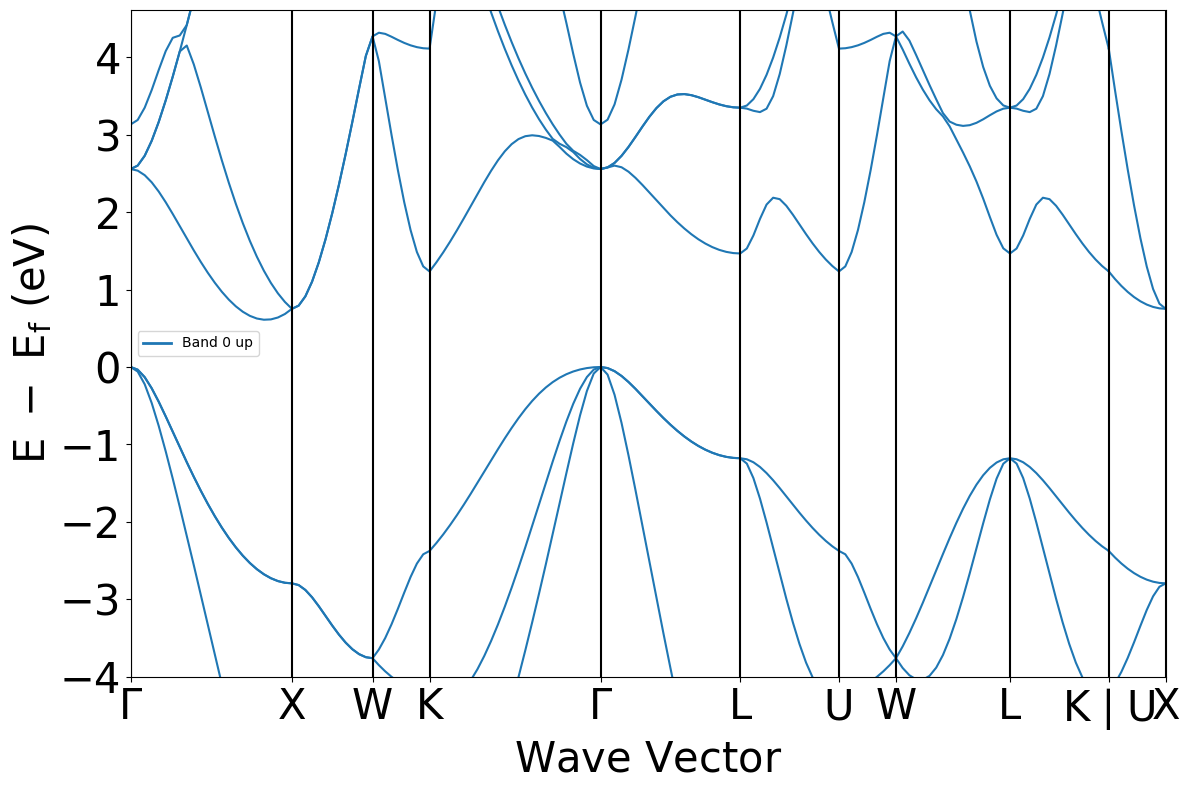

In [ ]:
plotter = BSPlotter(bs_sc)
plotter.get_plot()

## Density States for Silicon (mp-149)

In [ ]:
with MPRester(mpAPI) as mpr:
    dos = mpr.get_dos_by_material_id("mp-149")

normalized_dos = dos.get_normalized()
norm_vol = dos.structure.volume

Retrieving ElectronicStructureDoc documents: 100%|██████████| 1/1 [00:00<?, ?it/s]


<Axes: xlabel='Energies (eV)', ylabel='Density of states (states/eV/Å³)'>

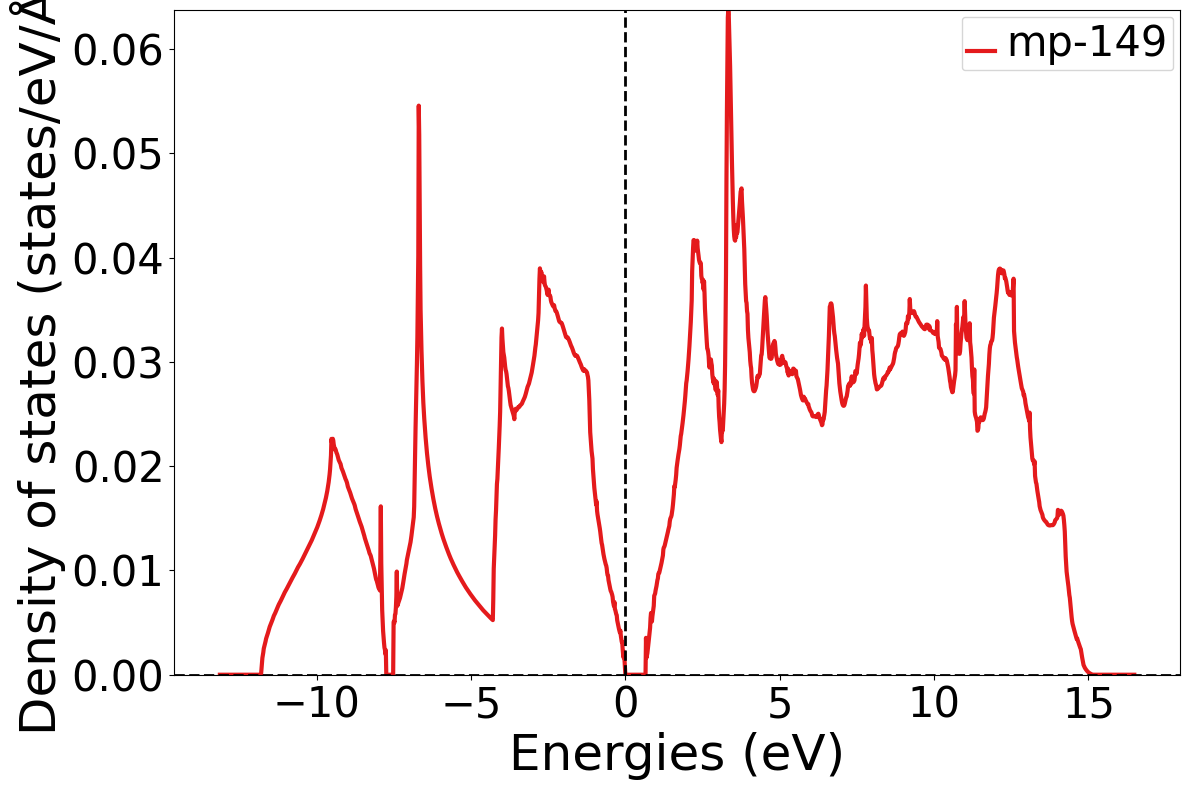

In [ ]:
plotter = DosPlotter()
plotter.add_dos("mp-149", normalized_dos)
plotter.get_plot()

## VASP Input Parameters (e.g. NELECT)

In [ ]:
with MPRester(mpAPI) as mpr:
    summary_doc = mpr.materials.summary.search(material_ids = ["mp-149"])[0]
    task_id = str(summary_doc.dos.total[Spin.up].task_id)
    task_doc = mpr.materials.tasks.search(task_ids = [task_id])[0]

print(task_doc.input.parameters.get("NELECT"))

Retrieving CoreTaskDoc documents: 100%|██████████| 1/1 [00:00<?, ?it/s]

8.0


In [46]:
task_doc.input

CalculationInput(incar={'SYSTEM': 'Mp-149', 'PREC': 'accurate', 'ALGO': 'Normal', 'ISPIN': 1, 'ICHARG': 11, 'NELM': 100, 'IBRION': -1, 'EDIFF': 1e-05, 'NSW': 0, 'ISIF': 3, 'ISYM': 2, 'ENCUT': 520.0, 'NBANDS': 10, 'NEDOS': 2001, 'LREAL': 'Auto', 'ISMEAR': -5, 'SIGMA': 0.05, 'LWAVE': False, 'LCHARG': False, 'LVHAR': True, 'LORBIT': 11, 'LASPH': True, 'LAECHG': True, 'KPOINT_BSE': [-1, 0, 0, 0]}, kpoints=Kpoints from vasprun.xml
0
Monkhorst
18 18 18
, nkpoints=570, potcar_spec=[PotcarSpec(titel='PAW_PBE Si 05Jan2001', hash='b2b0ea6feb62e7cde209616683b8f7f5', summary_stats=None)], potcar=['Si'], potcar_type=['PAW_PBE'], parameters={'SYSTEM': 'Mp-149', 'LCOMPAT': False, 'PREC': 'accura', 'ENMAX': 520.0, 'ENAUG': 322.069, 'EDIFF': 1e-05, 'IALGO': 38, 'IWAVPR': 10, 'NBANDS': 12, 'NELECT': 8.0, 'TURBO': 0, 'IRESTART': 0, 'NREBOOT': 0, 'NMIN': 0, 'EREF': 0.0, 'ISMEAR': -5, 'SIGMA': 0.05, 'KSPACING': 0.5, 'KGAMMA': True, 'LREAL': True, 'ROPT': [-0.00025], 'LMAXPAW': -100, 'LMAXMIX': 2, 'NLSPLINE

NOTE: Be aware that the POTCARs we use in calculations has changed over time, the value of NELECT is not always determined by the MPRelaxSet. If a DOS was generated with r2SCAN, then the right set to use is MPScanRelaxSet. The method above circumvents this by letting you directly retrieve the value of NELECT.

## Get task-id associated with DOS

In [52]:
with MPRester(mpAPI) as mpr:
    #electronic_structure is used to access all electronic structure related information
    #differences of this with summary is that this may include multiple entries for a given material_id
    estruct_doc = mpr.materials.electronic_structure.search(
        material_ids = ["mp-149"])[0]
    
    #Inspect task IDs
    print(f"DOS task ID = {estruct_doc.dos.total[Spin.up].task_id}")
    print(f"Band structure task ID = {estruct_doc.task_id}")

    #Retrieve the task corresponding to electronic DOS
    dos_task = mpr.materials.tasks.search(task_ids=[estruct_doc.dos.total[Spin.up].task_id])[0]

print(dos_task.task_id, dos_task.calc_type)

Retrieving ElectronicStructureDoc documents: 100%|██████████| 1/1 [00:00<?, ?it/s]


DOS task ID = mp-2250750
Band structure task ID = mp-1057384


Retrieving CoreTaskDoc documents: 100%|██████████| 1/1 [00:00<?, ?it/s]

2250750 GGA NSCF Uniform


# Phonons

## Band structure for silicon (mp-149)

In [60]:
with MPRester(mpAPI) as mpr:
    ph_bs = mpr.get_phonon_bandstructure_by_material_id("mp-149")

In [76]:
vars(ph_bs).keys()

dict_keys(['identifier', 'structure', 'path_convention', 'kpath', 'labels_dict', 'qpoints', 'reciprocal_lattice', 'has_nac', 'frequencies', 'eigendisplacements'])

## Density of states for silicon (mp-149)

In [77]:
with MPRester(mpAPI) as mpr:
    ph_dos = mpr.get_phonon_dos_by_material_id("mp-149")

In [81]:
vars(ph_dos).keys()

dict_keys(['identifier', 'structure', 'frequencies', 'densities', 'projected_densities'])